# K-Nearest Neighbors (KNN)

## Prerequisites:

To start with KNN, it is recommended that you are aware of the following basic concepts:
- Basic Machine Learning Terminology
- Common Distance / Similarity Measures
    - Euclidean Distance
    - Manhattan Distance 
    - Hamming Distance
    - Correlation Coefficient

## Learning Objective:

- Understand K-Nearest Neighbor (KNN) Classification
- Build KNN Classifiers using Python Scikit-Learn
- Interpret results with Confusion Matrix 
- Ability to Build Models for Real-World Dataset




K-nearest neighbors (KNN) is one of the simplest supervised machine learning algorithms that can be used for either regression or classification. The algorithm accepts a collection of training examples along with their respective targets and stores the data. It is worth pointing out that the "training" phase for KNN only involves storing the training samples; ball trees and k-D trees are some of the common data structures used for storage, but specifics on how data is stored and accessed is beyond the scope of this notebook. To predict the target of an unknown query point (i.e., sample), the k nearest neighbors are located. In the case of classification, a majority voting scheme is used to predict the class. In the case of regression, an aggregate scheme, such as the mean or median, is used to predict a continuous value. KNN is often referred to as an *instance-based learning*, *memory-based learning*, or *lazy learning* algorithm since most of the computation is deferred until predictions need to be made.

To locate the nearest neighbors, a distance or similarity function is required. While there are numerous distance and similarity functions available, [manhattan distance](https://en.wikipedia.org/wiki/Taxicab_geometry) is the most common when the samples contain real-valued features; this is because the manhattan distance is computationally simpler than the [euclidean distance](https://en.wikipedia.org/wiki/Euclidean_distance) and produces the same results. In the case of discrete features, the [hamming distance](https://en.wikipedia.org/wiki/Hamming_distance) is often used.

A flaw in k-nearest neighbors arises from the majority voting scheme when performing classification under a target class imbalance. This can be overcome by using a weighted voting scheme in which points further away from the query point are given a smaller weight when voting. This weighted scheme can be extended to regression problems as well.


## Imports


In [ ]:
from collections import defaultdict
import itertools

import matplotlib as mpl
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display, HTML

Function Definitions


In [ ]:
from utils import (
    display_classification_map, 
    display_training_samples, 
    data_generation,
    knn_neighbour,
    hist_scatter_plot,
)

## Synthetic Dataset

We are going to begin with a simple synthetic example to better understand KNN. We will first generate random clusters of points. Each cluster will consist of `n_points` points randomly chosen within the unit circle; the cluster centers are determined by the points within the `CENTERS` numpy array. The target class assigned to each point corresponds to the cluster it belongs too. Note that cluster centers have been chosen so that the clusters can overlap.

We can view our data using Matplotlib.


In [ ]:
n_points = 25
random = np.random.RandomState(0)
CENTERS = np.asarray([
    [0.5, 0.5],
    [-0.5, -0.5],
])
my_cmap = mpl.colors.ListedColormap(["green", "blue"])
colors = my_cmap(np.linspace(0., 1., len(CENTERS)))

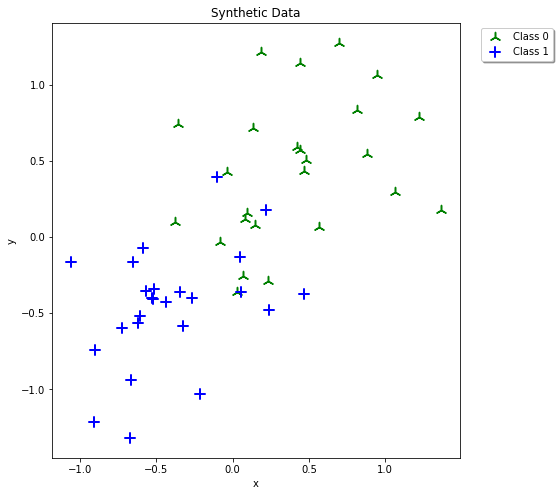

In [ ]:
X, y = data_generation(CENTERS, random, n_points, colors)

### Building a KNN Model

We are going to use the [`KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) object from Scikit-Learn for KNN classification (the [KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#sklearn.neighbors.KNeighborsRegressor) object can be used for regression). Some useful parameters of the `KNeighborsClassifier` constructor are `n_neighbors`, `weights`, and `metric`:
  * `n_neighbors` - sets the user-defined k parameter to KNN
  * `weights` - used to set a majority or weighted voting scheme
  * `metric` - used to set the distance function used
  
We begin by using the [`fit`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier.fit) method to create our model. After creating random query points, we can use the [`predict`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier.predict) method to classify the query points based on our KNN model. In addition, the [`kneighbors`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier.kneighbors) method can be used to obtain the k nearest neighbors to each query point.


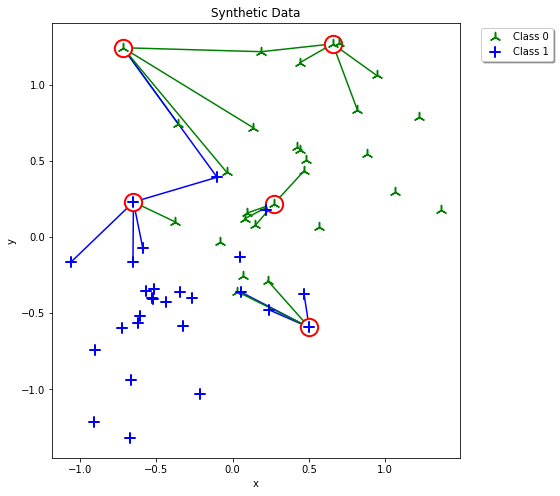

In [ ]:
# Import KNeighborsClassifier from sklearn.neighbors
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X,y)

# Create & Classify Random Query Points
X_hat = random.uniform(low=X.min(), high=X.max(), size=(5,2))
y_hat = knn.predict(X_hat)

knn_neighbour(X, y, X_hat, y_hat, knn, colors)

In the previous figure, each of the query points is surrounded by a red circle, and the query points are drawn to match their predicted class. You can also see lines drawn from the query points to their $k=5$ nearest neighbors. We can see that the bottommost query point was predicted to be Class 1, because it has two Class 0 neighbors and three Class 1 neighbors. The top left query point was predicted to be Class 0, because it has four Class 0 neighbors and one Class 1 neighbor.


### KNN Classification Map

Since our synthetic data is two dimensional, we can create a KNN classification map; a KNN classification map allows us to visualize the regions of our space that correspond to the different targets.


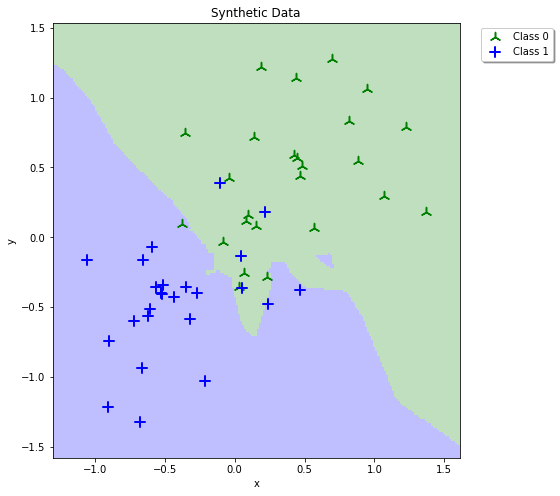

In [ ]:
my_cmap = mpl.colors.ListedColormap(["green", "blue"])
display_classification_map(
    X,
    y,
    knn,
    CENTERS,
    title="Synthetic Data",
    xlabel="x",
    ylabel="y",
    figsize=(8,8),
    cmap=my_cmap
)

In the above classification map, any point that lies within the light-green shaded area will be classified as Class 0, while any point within the light-blue shaded area will be classified as Class 1. We can see that there is a single Class 0 point that lies within the light-blue shaded area; the area around this point is shaded light-blue because there are more Class 1 points closer to this area than there are Class 0 points. We can also see that several Class 1 points lie within the light-green shaded area for the same reason.

If we were to apply a weighted voting scheme, no training sample will end up misclassified.


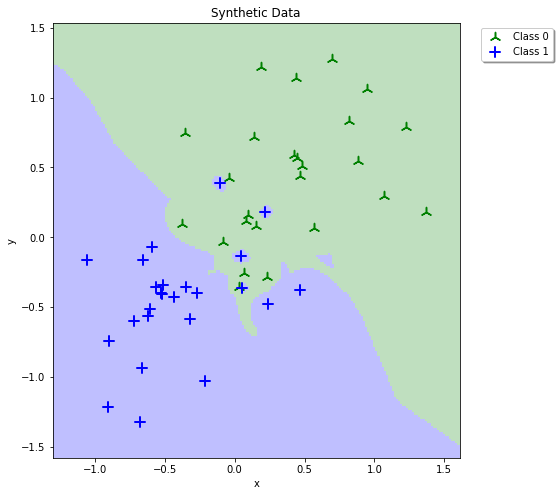

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5, weights="distance")
knn.fit(X,y)

display_classification_map(
    X,
    y,
    knn,
    CENTERS,
    title="Synthetic Data",
    xlabel="x",
    ylabel="y",
    figsize=(8,8),
    cmap=my_cmap
)

From this new classification map, we can see that every training point lies within an area matching its class. There are a few light-blue regions that lie within the larger light-green region. These most likely correspond to outliers. While a weighted voting scheme ensures that no training point is misclassified, it is susceptible to outliers, and care should be taken when deciding between a majority and a weighted voting scheme.


## Iris Dataset

Fisher's iris dataset is a popular multivariate dataset often used in machine learning. The dataset consists of 150 samples evenly distributed among three species of iris: iris setosa, iris virginica, iris versicolor. Each sample consists of four attributes: the length and width, in centimenters, of the sepals and the petals. The task is to predict which class an unidentified iris plant belongs based on the sepal and petal measurements.
  * https://archive.ics.uci.edu/ml/datasets/iris


In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()

data_df=pd.DataFrame({
    'Sepal Length':iris.data[:,0],
    'Sepal Width':iris.data[:,1],
    'Petal Length':iris.data[:,2],
    'Petal Width':iris.data[:,3],
    'Class':iris.target
})

features = data_df.columns[:-1]
targets = np.unique(data_df["Class"])

data_df.head()

,Sepal Length,Sepal Width,Petal Length,Petal Width,Class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


**Scatterplots**

To get a better understanding of the relationship between the sample features and the target class, we are going to plot the features against one another. This can help give us an idea of how the length and width of the sepals and petals relate to the type of flower. We will also include a histogram for each feature.


In [ ]:
my_cmap = mpl.colors.LinearSegmentedColormap.from_list("RGB", [(1,0,0), (0,1,0), (0,0,1)])

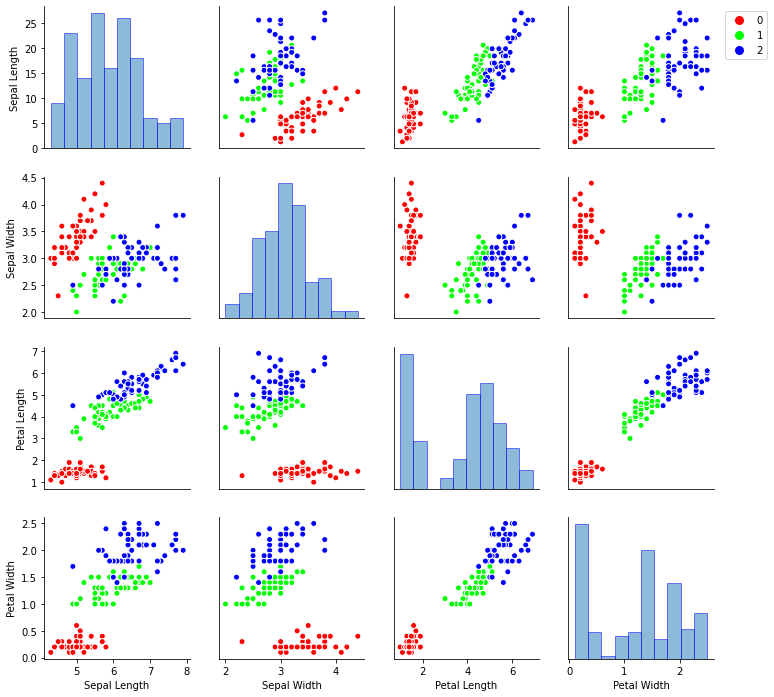

In [ ]:
hist_scatter_plot(features, targets, data_df)

From the previous figure, we can see that some pairs of features tend to have a better separation between the targets than others. For example, consider the plot of `Sepal Length` versus `Sepal Width`; we can see that there appears to be a lot of spatial overlap between the `Iris-versicolor` and the `Iris-virginica` classes. On the other hand, from the plot of `Petal Length` versus `Petal Width`, there does not appear to be as much overlap in the target classes.


### Build KNN Model 1 (Sepal Length & Sepal Width)

Let us use the `Sepal Length` and `Sepal Width` features to build a KNN model. This will show us how useful the length and width of the sepals are at determining the iris species.


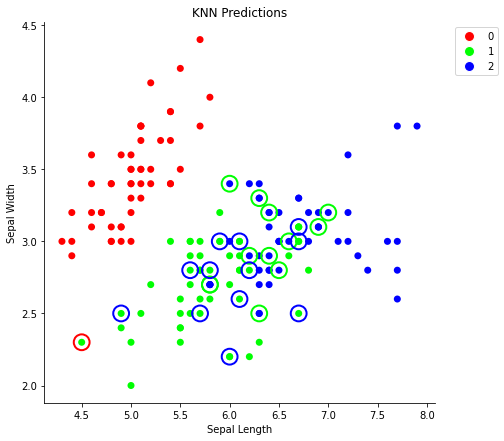

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(data_df[["Sepal Length", "Sepal Width"]], data_df["Class"])
y_hat = knn.predict(data_df[["Sepal Length", "Sepal Width"]])

display_training_samples(
    data_df[["Sepal Length", "Sepal Width"]].values,
    data_df["Class"].values,
    y_pred=y_hat,
    title="KNN Predictions",
    xlabel="Sepal Length",
    ylabel="Sepal Width",
    figsize=(7,7),
    cmap=my_cmap
)

We can see the results of the KNN classification using `Sepal Length` and `Sepal Width` in the previous figure. Each of the solid colored circles represents a sample, while the color of the circle corresponds to the class predicted by KNN. For those samples in which KNN predicted the class incorrectly, and colored ring indicating the true class appears around the circle.

From the plot, we can see that several samples were misclassified. However, it is difficult to get an intuitive idea of which classes the algorithm is struggling with. To get a better understanding of where KNN is failing, we can construct a confusion matrix to visualize the performance of the algorithm.


**Confusion Matrix**

A confusion matrix is a 2d array in which the rows and columns are indexed by the different possible classes. The rows of the matrix represent instances of observed classes, while columns represent instances of predicted classes. That is to say, given a confusion matrix $C$, the entry $c_{i,j}$ is the number of observations known to belong to class $i$ but predicted to be in class $j$.

We can use the [confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) function from the [sklearn.metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics) module to calculate the confusion matrix.


In [ ]:
# Import confusion_matrix from sklearn.metrics
from sklearn.metrics import confusion_matrix

labels = data_df["Class"].unique()
matrix = confusion_matrix(data_df["Class"], y_hat, labels=labels, normalize=None)
print(matrix)

[[49  1  0]
 [ 0 38 12]
 [ 0 12 38]]


The Scikit-Learn function [`plot_confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.plot_confusion_matrix.html) can be used to create and plot a nice visualization of a confusion matrix using matplotlib. The function calculates the confusion matrix given a collection of inputs along with their targets, and it returns a [ConfusionMatrixDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay) object. The confusion matrix can be accessed through the `confusion_matrix` member variable of the returned `ConfusionMatrixDisplay` object.


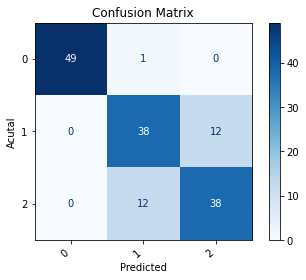

In [ ]:
from sklearn.metrics import plot_confusion_matrix

disp = plot_confusion_matrix(
    knn,
    data_df[["Sepal Length", "Sepal Width"]],
    data_df["Class"],
    labels=data_df["Class"].unique(),
    xticks_rotation=40,
    cmap="Blues"
)

disp.ax_.set_xticklabels(data_df["Class"].unique(), rotation=40, ha="right")
disp.ax_.set_title("Confusion Matrix")
disp.ax_.set_xlabel("Predicted")
disp.ax_.set_ylabel("Acutal")
plt.show()


The previous figure shows the confusion matrix for our KNN model. From the **second row** of the confusion matrix, we can see that
- 0 of the Iris-versicolor samples were incorrectly predicted as Iris-setosa,
- 38 of the Iris-versicolor samples were correctly predicted as Iris-versicolor, and
- 12 of the Iris-versicolor samples were incorrectly predicted as Iris-virginica.

From the **second column** of the confusion matrix, we can see that
- 1 instance of Iris-setosa samples was incorrectly predicted to be Iris-versicolor,
- 38 instances of Iris-versicolor were correctly predicted as Iris-versicolor, and
- 12 instances of Iris-virginica were incorrectly predicted to be Iris-versicolor.

From the results, we can see that the length and width of the sepals is good at distinguishing the iris setosa from the iris versicolor and iris virginica. However, these attributes are not very useful when distinguishing between the iris versicolor and iris virginica.


### Build KNN Model 2 (Petal Length & Petal Width)

To see how effective the length and width of the petals are at determining the iris species, we will build a new KNN model using the `Petal Length` and `Petal Width` features.


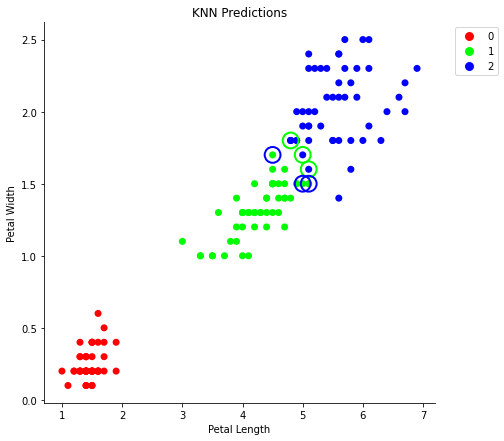

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(data_df[["Petal Length", "Petal Width"]], data_df["Class"])
y_hat = knn.predict(data_df[["Petal Length", "Petal Width"]])
    
display_training_samples(
    data_df[["Petal Length", "Petal Width"]].values,
    data_df["Class"].values,
    y_pred=y_hat,
    title="KNN Predictions",
    xlabel="Petal Length",
    ylabel="Petal Width",
    figsize=(7,7),
    cmap=my_cmap
)

From the above plot, we can see that there are fewer misclassified training samples under the KNN model built using the length and width of the petals. And so, it appears that the `Petal Length` and `Petal Width` features lead to a better KNN model than the `Sepal Length` and `Sepal Width` features. To verify this, we can turn to the confusion matrix of this new model.


In [ ]:
disp = plot_confusion_matrix(
    knn,
    data_df[["Petal Length", "Petal Width"]],
    data_df["Class"],
    labels=data_df["Class"].unique(),
    xticks_rotation=40,
    cmap="Blues"
)
disp.ax_.set_xticklabels(data_df["Class"].unique(), rotation=40, ha="right")
disp.ax_.set_title("Confusion Matrix")
disp.ax_.set_xlabel("Predicted")
disp.ax_.set_ylabel("Acutal")
plt.show()

From the confusion matrix, we can see that our new model is better at distinguishing between iris versicolor and iris virginica than our first model. However, there are still some issues near the boundary of the two classes.


### Build KNN Model 3 (Sepal Length, Sepal Width, Petal Length & Petal Width)

From the previous results, it appears that the length and width of the petals are better at determining the iris species than the length and width of the sepals. We are now going to build a model that uses all available features for classification. Unlike the previous models, we will be forced to rely on the confusion matrix to understand how well the model performs.


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(data_df[["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"]], data_df["Class"])

disp = plot_confusion_matrix(
    knn,
    data_df[["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"]],
    data_df["Class"],
    labels=data_df["Class"].unique(),
    xticks_rotation=40,
    cmap="Blues"
)
disp.ax_.set_xticklabels(data_df["Class"].unique(), rotation=40, ha="right")
disp.ax_.set_title("Confusion Matrix")
disp.ax_.set_xlabel("Predicted")
disp.ax_.set_ylabel("Acutal")
plt.show()

Based on this confusion matrix, it seems that the KNN model built using all of the features is performing very well. Given the different confusion matrices, it even appears that this latest model, which uses all features, is outperforming our second model, which only uses the length and width of the petals. One should take special care when reaching this conclusion. <font color="red">Measuring performance based on the training data is one of the common pitfalls of machine learning, and we need to leverage other techniques (e.g., k-fold cross-validation) to determine which of our models is best.</font>


## Additional Resources:

* Articles
 
 - [A Complete Guide to K-Nearest-Neighbors with Applications in Python and R](https://kevinzakka.github.io/2016/07/13/k-nearest-neighbor/)

